# Will I Attend the 8 AM Class?

A small decision tree project that tries to predict whether a student shows up to an 8 AM class, based on how much sleep they got and how far they live from campus.

The dataset is made up by hand (7 rows), so this is really just a walkthrough of the workflow - collect data, explore it, train a model, check it, use it - not a serious study of anyone's habits.

## The problem

We're predicting one thing: did the student attend their 8 AM class, yes or no.

- **Inputs (features):** sleep_hours, distance_km
- **Output (target):** attended_8am (1 = attended, 0 = did not)

Since the answer is one of two options, this is a binary classification problem.

## Imports

Pandas for the data, matplotlib for plotting, scikit-learn for the model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

## The dataset

Seven students, entered by hand. sleep_hours was calculated from sleep_time to wake_up_time, handling the cases where sleep starts after midnight (e.g. sleeping at 01:30 and waking at 07:30 is 6 hours, not negative).

In [2]:
data = {
    "student_id":    ["S1", "S2", "S3", "S4", "S5", "S6", "S7"],
    "sleep_time":    ["23:00", "01:30", "00:45", "22:30", "02:00", "23:45", "03:00"],
    "wake_up_time":  ["06:30", "07:30", "08:15", "05:45", "07:00", "06:00", "07:45"],
    "sleep_hours":   [7.50, 6.00, 7.50, 7.25, 5.00, 6.25, 4.75],
    "breakfast":     ["Yes", "No", "No", "Yes", "No", "Yes", "No"],
    "distance_km":   [1.2, 3.5, 5.0, 0.8, 2.0, 1.5, 4.2],
    "attended_8am":  [1, 1, 0, 1, 0, 1, 0],
}

df = pd.DataFrame(data)
df

,student_id,sleep_time,wake_up_time,sleep_hours,breakfast,distance_km,attended_8am
0,S1,23:00,06:30,7.50,Yes,1.2,1
1,S2,01:30,07:30,6.00,No,3.5,1
2,S3,00:45,08:15,7.50,No,5.0,0
3,S4,22:30,05:45,7.25,Yes,0.8,1
4,S5,02:00,07:00,5.00,No,2.0,0
5,S6,23:45,06:00,6.25,Yes,1.5,1
6,S7,03:00,07:45,4.75,No,4.2,0


## A quick look at the data

Shape, column types, and missing values, just to sanity check before doing anything else.

In [3]:
df.shape

(7, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   student_id    7 non-null      object 
 1   sleep_time    7 non-null      object 
 2   wake_up_time  7 non-null      object 
 3   sleep_hours   7 non-null      float64
 4   breakfast     7 non-null      object 
 5   distance_km   7 non-null      float64
 6   attended_8am  7 non-null      int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 520.0+ bytes


In [5]:
df.isnull().sum()

student_id      0
sleep_time      0
wake_up_time    0
sleep_hours     0
breakfast       0
distance_km     0
attended_8am    0
dtype: int64

How many attended vs. didn't:

In [6]:
df["attended_8am"].value_counts()

attended_8am
1    4
0    3
Name: count, dtype: int64

Average sleep and distance, split by whether the student attended:

In [7]:
df.groupby("attended_8am")[["sleep_hours", "distance_km"]].mean()

,sleep_hours,distance_km
attended_8am,,
0,5.75,3.733333
1,6.75,1.750000


## Attendance counts

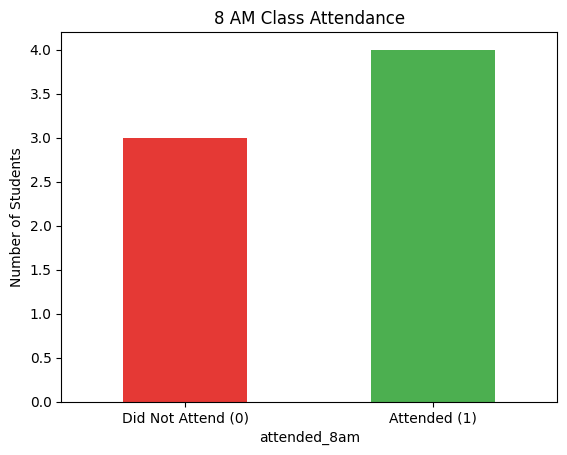

In [8]:
df["attended_8am"].value_counts().sort_index().plot(
    kind="bar", color=["#E53935", "#4CAF50"]
)
plt.xticks([0, 1], ["Did Not Attend (0)", "Attended (1)"], rotation=0)
plt.ylabel("Number of Students")
plt.title("8 AM Class Attendance")
plt.show()

## Sleep vs. distance

Green dots are students who attended, red dots didn't.

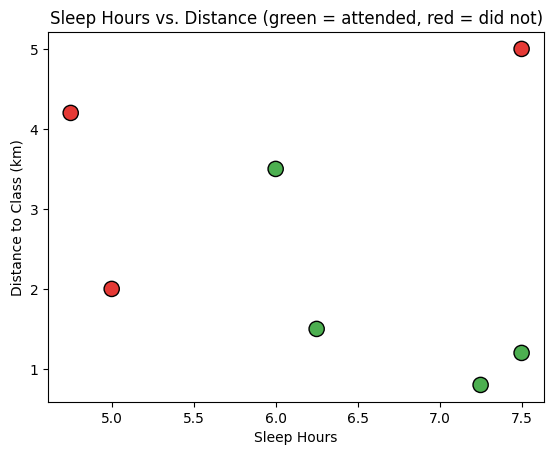

In [9]:
colors = df["attended_8am"].map({1: "#4CAF50", 0: "#E53935"})
plt.scatter(df["sleep_hours"], df["distance_km"], c=colors, s=120, edgecolor="black")
plt.xlabel("Sleep Hours")
plt.ylabel("Distance to Class (km)")
plt.title("Sleep Hours vs. Distance (green = attended, red = did not)")
plt.show()

## Features and target

Using sleep_hours and distance_km as the features. Leaving breakfast out for now since it's a text column and would need encoding first.

In [10]:
X = df[["sleep_hours", "distance_km"]]
y = df["attended_8am"]

## Train/test split

Only 7 rows total, so the test set is just 2 rows, with a fixed random_state for reproducibility. Not enough data to trust the results, but enough to run through the steps.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 5
Testing rows: 2


## The model

A decision tree, kept shallow (max_depth=2) so it stays readable.

In [12]:
model = DecisionTreeClassifier(max_depth=2, random_state=42)

Fit it on the training data:

In [13]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predictions on the test set

In [14]:
y_pred = model.predict(X_test)

print("Actual:    ", list(y_test.values))
print("Predicted: ", list(y_pred))

Actual:     [np.int64(1), np.int64(1)]
Predicted:  [np.int64(1), np.int64(0)]


## Accuracy

Worth noting: with only 2 test rows, this number doesn't mean much statistically. It just confirms the pipeline runs correctly end to end.

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


## Looking at the tree

Each box shows the question being asked, how many training samples reached it, and which class it leans toward.

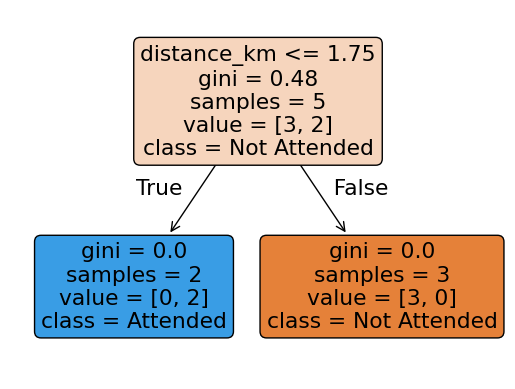

In [16]:
plt.figure()
plot_tree(
    model,
    feature_names=["sleep_hours", "distance_km"],
    class_names=["Not Attended", "Attended"],
    filled=True,
    rounded=True
)
plt.show()

## Trying a new example

A made-up student, just to see what the model predicts.

In [17]:
new_student = pd.DataFrame({
    "sleep_hours": [7.0],
    "distance_km": [2.5]
})

prediction = model.predict(new_student)[0]
print("Predicted attendance (1 = Yes, 0 = No):", prediction)

Predicted attendance (1 = Yes, 0 = No): 0
